# CSAF Figures

## Dataset loading

In [26]:
import pandas as pd
import numpy as np
import pygmt
import rasterio

import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

from pyproj import Proj, Geod
P = Proj('epsg:32610')
G = Geod(ellps='WGS84')

In [27]:
# Open results
par750 = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Profiles/20260402/ErfProfileResults_ProfLen750_SwathWidth10_10mSpacing_parFILTERED.csv')
perp750 = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Profiles/20260402/ErfProfileResults_ProfLen750_SwathWidth10_10mSpacing_perpFILTERED.csv')


In [38]:
# Parkfield lat/lon → convert to your CRS
Px, Py = P(-120.441, 35.899)

icpdf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/FromChelsea/Creep_rates_plot/Creep_results_Scott_et_al_withHeader.txt',sep='\s+')
icpdf["dist_from_parkfield_m"] = np.sqrt(
    (icpdf.X - Px)**2 +
    (icpdf.Y - Py)**2
)

cdf = pd.read_csv('/Users/chanagan/Downloads/JohnsonEtAl2022CreepTable.csv')
cdf = cdf[((cdf.Latitude >= 35.8) & (cdf.Longitude <= 37.15))]

cdf['easting'] = P(cdf['Longitude'].values,cdf['Latitude'].values)[0]
cdf['northing'] = P(cdf['Longitude'].values,cdf['Latitude'].values)[1]
cdf["dist_from_parkfield_m"] = np.sqrt(
    (cdf.easting - Px)**2 +
    (cdf.northing - Py)**2
)
cdf = cdf[cdf.dist_from_parkfield_m < 150*1000]
# Enumerate inst type of creep rate measurements
cdf['Inst_i'] = np.empty(len(cdf))
cdf['Aperture'] = np.empty(len(cdf))
#'AA', 'CM', 'Cult', 'GPS', 'Geod', 'LiDAR', 'SAR'
aps = [100,70,10,5000,10000,1000,1000]
for i, inst, ap in zip(np.arange(len(np.unique(cdf.Inst))),np.unique(cdf.Inst),aps):
    cdf.loc[cdf['Inst'] == inst, 'Inst_i'] = np.ones(len(cdf[cdf.Inst == inst]))*i
    cdf.loc[cdf['Inst'] == inst, 'Aperture'] = np.ones(len(cdf[cdf.Inst == inst]))*ap


xudf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_SAFCreep.txt',sep='\s+',comment='#',skiprows=3,header=None)
xudf.columns = ['lon','lat','creep','vert','creep_uncertainty','vert_uncertainty']
xudf['easting'] = P(xudf['lon'].values,xudf['lat'].values)[0]
xudf['northing'] = P(xudf['lon'].values,xudf['lat'].values)[1]
xudf = xudf[(xudf.easting < icpdf.X.max())&
            (xudf.easting > icpdf.X.min())&
            (xudf.northing < icpdf.Y.max())&
            (xudf.northing > icpdf.Y.min())]
xudf["dist_from_parkfield_m"] = np.sqrt(
    (xudf.easting - Px)**2 +
    (xudf.northing - Py)**2
)

bhdf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/GIS/FinalFaultGeomFiles/BurfordandHarsh.csv')
bhdf = bhdf[bhdf.Key == True]
bhdf.replace(-9999,np.nan,inplace=True)
# Change datum from BH likely NAD27 to WGS84
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4267", "EPSG:4326", always_xy=True)
bhdf['Lon84'],bhdf['Lat84'] = transformer.transform(bhdf['Longitude_W'],bhdf['Latitude_N'])
bhdf['Lon84'] = bhdf['Lon84'].values *-1
bhdf['easting'] = P(bhdf['Lon84'].values,bhdf['Lat84'].values)[0]
bhdf['northing'] = P(bhdf['Lon84'].values,bhdf['Lat84'].values)[1]
bhdf["dist_from_parkfield_m"] = np.sqrt(
    (bhdf.easting - Px)**2 +
    (bhdf.northing - Py)**2
)

aaERFdf = pd.read_csv('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/AlignmentArrayERF_ALL_PAIRS_NEW.csv')
aaERFdf = aaERFdf[aaERFdf['Name'] != 'Topo Creek']
aaERFdf["dist_from_parkfield_m"] = np.sqrt(
    (aaERFdf['Easting (m)'] - Px)**2 +
    (aaERFdf['Northing (m)'] - Py)**2
)

lidERFdf = pd.read_csv('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/LidarAtAlignmentArrayERF_ALL_PAIRS_NEW.csv')
lidERFdf = lidERFdf[lidERFdf['Name'] != 'Topo Creek']
lidERFdf["dist_from_parkfield_m"] = np.sqrt(
    (lidERFdf['Easting (m)'] - Px)**2 +
    (lidERFdf['Northing (m)'] - Py)**2
)
bhdf_found = bhdf[bhdf.Site_Name.isin(lidERFdf.Name)]

sarERFdf = pd.read_csv('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSAR30.0AtAlignmentArrayERF_ALL_PAIRS_NEW.csv')
sarERFdf = sarERFdf[sarERFdf['Name'] != 'Topo Creek']
sarERFdf["dist_from_parkfield_m"] = np.sqrt(
    (sarERFdf['Easting (m)'] - Px)**2 +
    (sarERFdf['Northing (m)'] - Py)**2
)

gnss = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/cwu.final_nam14.vel',skiprows=35,sep='\s+')

# RTK AA
f = '/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/AlignmentArrayVelocities_SingleLTandST_NEW.csv'
aartk = pd.read_csv(f,comment='#')
aartk.replace(-9999, np.nan, inplace=True)
aartk = aartk[aartk['Name'] != 'Topo Creek']
aartk['easting'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[0]
aartk['northing'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[1]
aartk["dist_from_parkfield_m"] = np.sqrt(
    (aartk.easting - Px)**2 +
    (aartk.northing - Py)**2
)



<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:80: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:80: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_90428/2683643495.py

## Overview map

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
from shapely import wkt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import math
import pygmt 

In [5]:
# Bounding box
overview_region = [-122.0,-120.1,35.8,37.15]

grid = pygmt.datasets.load_earth_relief(
    resolution='15s',
    region=overview_region,
    use_srtm=True)

dgrid = pygmt.grdgradient(grid=grid, radiance=[270, 40])


In [6]:
df = gnss[['Ref_Elong','Ref_Nlat','dE/dt','dN/dt']]
df['Ref_Elong'] = df['Ref_Elong'] - 360
df.columns = ['x','y','east_velocity','north_velocity']
# remove mean between pea1 and 2
refN = (gnss[gnss['*Dot#'] == 'PEA1']['dN/dt'].iloc[0] + gnss[gnss['*Dot#'] == 'PEA2']['dN/dt'].iloc[0])/2
refE = (gnss[gnss['*Dot#'] == 'PEA1']['dE/dt'].iloc[0] + gnss[gnss['*Dot#'] == 'PEA2']['dE/dt'].iloc[0])/2
df['east_velocity'] = df['east_velocity'] - refE
df['north_velocity'] = df['north_velocity'] - refN
df['east_sigma'] = np.zeros(len(df))
df['north_sigma'] = np.zeros(len(df))
df['correlation_EN'] = np.zeros(len(df))

In [ ]:
# Include overview with lidar 
# qfaults
# aa locations, gps locations

# --- Plot with PyGMT ---
fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")
pygmt.config(FONT_ANNOT="8p,Helvetica,black")

fig.basemap(region=overview_region, projection="M11c", frame=["WNse", "af"])
fig.coast(water="skyblue")

# Hillshade
pygmt.makecpt(cmap="gray", series=[-1.5, 0.3, 0.01])
fig.grdimage(grid=dgrid,cmap=True,transparency=40)

fig.plot('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp')

fig.velo(data=df,spec="e75/0.95",pen="0.8p,maroon",line=True,vector="0.25c+p1p+e+gmaroon")
fig.text(x=gnss[gnss['*Dot#'] == 'PEA1'].Ref_Elong.iloc[0],y=gnss[gnss['*Dot#'] == 'PEA1'].Ref_Nlat.iloc[0],
         text='PEA1',justify='BL',clearance='0.2c/0.2c')
fig.velo(data={'x':-121.9, 
               'y':36.1, 
               'east_velocity':0.02, 
               'north_velocity':0, 
               'east_sigma':0,
               'north_sigma':0, 
               'correlation_EN':0},
               spec="e75/0.95",pen="0.8p,maroon",line=True,vector="0.25c+p1p+e+gmaroon")
fig.text(x=-121.85,y=36.05,text='2 cm/yr',justify='BL',clearance='0.2c/0.2c')

fig.plot(x=bhdf.Lon84,y=bhdf.Lat84,style="s0.4c", fill="steelblue",pen="0.1p,black",label='Alignment Array')
fig.text(x=bhdf.Lon,y=bhdf.Lat,text=bhdf.AA,justify='BL',clearance='0.2c/0.2c')

# Scale Bar
fig.basemap(map_scale='JBL+w10k+o-1c/-1c+lkm',box="+c0.1/0.3+gwhite@30+p0.5p,grey@30,solid")
fig.legend(position="jBL+o1.2c/0.3c+l2")

with fig.inset(
    position="jTR+o-1.5c/-1.5c",
    margin='1c',
    region='US.CA',
    projection="M6c",
):
    fig.coast(
        region='US.CA',
        dcw="US.CA+p0.6p,black+gwhite",
        land='white',
        borders='1',
        water='skyblue3',
        frame=["ENsw", "a"],
    )
    rectangle = [[overview_region[0], overview_region[2], overview_region[1], overview_region[3]]]
    fig.plot(data='/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp', pen="0.2p,darkgrey")
    fig.plot(data=rectangle,style="r+s", pen="0.7p,black")

fig.savefig('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/IntroCSAFMap.pdf',dpi=300)

# Export or show
fig.show()

## Aperture test, swath width test, data pruning test

In [ ]:
pdf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/CurrentProfileFits/Spaced100m/ErfProfileResults_ProfLen1000_SwathWidth100_SAF_flagged.csv')
pdf["dist_from_parkfield_m"] = np.sqrt(
    (pdf.easting - Px)**2 +
    (pdf.northing - Py)**2
)
pardf = pdf[pdf['par_ok'] == 'y']
perpdf = pdf[pdf['perp_ok'] == 'y']

In [ ]:
def rolling_dist_median(dist, vel, window_m):
    half_w = window_m / 2
    npts = len(vel)
    # Prepare arrays for results
    rolling_median = np.full(npts, np.nan)
    rolling_mad = np.full(npts, np.nan)

    # Compute rolling median in a *distance window*
    for i in range(npts):
        # distance window: +/- 500 m
        lo = dist[i] - half_w
        hi = dist[i] + half_w

        mask = (dist >= lo) & (dist <= hi)
        vals = vel[mask]

        if len(vals) > 0:
            rolling_median[i] = np.median(vals)
            rolling_mad[i] = np.median(np.abs(vals - np.median(vals)))
    return rolling_median, rolling_mad

In [ ]:
# Central San Andreas Fault Creep Rate from Full erf Fit
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(10, 3.5))

for pts, color in zip([saf200,saf500,saf1500], ['teal','maroon','indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    npts = len(pts)


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        pts['par_rolling_median'],
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'1 km Rolling Median ({fname})',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        pts['par_rolling_median'] - pts['par_rolling_mad'],
        pts['par_rolling_median'] + pts['par_rolling_mad'],
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )


# ICP data
plt.scatter(
    icpdf["dist_from_parkfield_m"],
    icpdf.NWRate / 10,
    s=1,
    color='lightpink',
    label='S20 ICP NW velocity',
    zorder=5
)
## InSAR data
plt.plot(
    xudf["dist_from_parkfield_m"],
    xudf.creep / -10,
    color='grey',
    label='Xu21 InSAR',
    zorder=5
)
# New AA lt rates
plt.errorbar(
    egdf["dist_from_parkfield_m"],
    -1 * egdf.par_total_offset,
    yerr=egdf.par_total_offset_sig,
    fmt='^',
    markersize=6,
    color='black',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    label='LT AA (1 sig)',
    zorder=20
)
plt.errorbar(
    egdf["dist_from_parkfield_m"],
    -1 * egdf.par_lidswath200l10w_total_offset,
    yerr=egdf.par_lidswath200l10w_total_offset_sig,
    fmt='^',
    markersize=6,
    color='teal',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    label='Lidar@AA (1 sig)',
    zorder=20
)

# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )

# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Parallel Velocity (cm/yr)')
plt.title('Central San Andreas Fault Creep Rate from Full erf Fit')

plt.legend(loc='upper left'
   #bbox_to_anchor=(-1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

In [ ]:
# Cleaned erf fits vs full fits, parallel
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(10, 3.5))

for pts, color in zip([saf1500], ['indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    npts = len(pts)


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        pts['par_rolling_median'],
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'1 km Rolling Median FULL',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        pts['par_rolling_median'] - pts['par_rolling_mad'],
        pts['par_rolling_median'] + pts['par_rolling_mad'],
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )
pts = pardf.sort_values("dist_from_parkfield_m").reset_index(drop=True)

rolling_median, rolling_mad = rolling_dist_median(pts.dist_from_parkfield_m.values,
                    -1*pts[f'par_total_offset'].values, window_m=1000)
    
# Plot rolling median line (x-axis = distance)
plt.plot(
    pts.dist_from_parkfield_m.values,
    rolling_median,
    color='teal',
    #s=0.7,
    linewidth=1,
    label=f'1 km Rolling Median CLEAN',
    zorder=7
)
## Plot shaded MAD bounds
plt.fill_between(
    pts.dist_from_parkfield_m.values,
    rolling_median - rolling_mad,
    rolling_median + rolling_mad,
    color='teal',
    alpha=0.2,
    label=f"± MAD"
)
# New AA lt rates
plt.errorbar(
    egdf["dist_from_parkfield_m"],
    -1 * egdf.par_total_offset,
    yerr=egdf.par_total_offset_sig,
    fmt='^',
    markersize=6,
    color='black',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    label='LT AA (1 sig)',
    zorder=20
)

# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )
# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Parallel Velocity (cm/yr)')
plt.title('Central San Andreas Fault Creep Rate from All vs Trimmed erf Fit')

plt.legend(loc='upper left'
   #bbox_to_anchor=(-1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

In [ ]:
# Cleaned erf fits vs full fits, parallel
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(9, 3.5))

for pts, color in zip([saf500], ['teal']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    npts = len(pts)


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        pts['par_rolling_median'],
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'1 km Rolling Median',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        pts['par_rolling_median'] - pts['par_rolling_mad'],
        pts['par_rolling_median'] + pts['par_rolling_mad'],
        color=color,
        alpha=0.2,
        label=f"± MAD"
    )
# ICP data
plt.scatter(
    icpdf["dist_from_parkfield_m"],
    icpdf.NWRate / 10,
    s=1,
    color='lightpink',
    label='S20 ICP NW velocity',
    zorder=5
)
## InSAR data
plt.plot(
    xudf["dist_from_parkfield_m"],
    xudf.creep / -10,
    color='grey',
    label='Xu21 InSAR',
    zorder=5
)
# New AA lt rates
plt.errorbar(
    egdf["dist_from_parkfield_m"],
    -1 * egdf.par_total_offset,
    yerr=egdf.par_total_offset_sig,
    fmt='^',
    markersize=6,
    color='black',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    label='Long-term AA (1 sig)',
    zorder=20
)
# Lidar at AA
plt.errorbar(
    egdf["dist_from_parkfield_m"],
    -1 * egdf.par_lidswath200l10w_total_offset,
    yerr=egdf.par_lidswath200l10w_total_offset_sig,
    fmt='^',
    markersize=6,
    color='teal',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    label='Lidar@AA (1 sig)',
    zorder=20
)
# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )
# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Parallel Velocity (cm/yr)')
plt.title('Central San Andreas Fault Creep Rate from All vs Trimmed erf Fit')

plt.legend(loc='upper left'
   #bbox_to_anchor=(-1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
plt.savefig(
   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison.pdf'
)
plt.show()

In [ ]:
# Cleaned erf fits vs full fits, perpendicular
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(10, 3.5))

for pts, color in zip([saf1500], ['indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    npts = len(pts)

    #plt.scatter(pts.dist_from_parkfield_m.values,
    #-1*pts[f'perp_total_offset'].values,
    #color=color,
    #s=0.7,
    #alpha=0.5,
    #linewidth=1,
    #label=f'ERF Rate ({fname})',
    #zorder=7
    #)
    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        pts['perp_rolling_median'],
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'1 km Rolling Median FULL',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        pts['perp_rolling_median'] - pts['perp_rolling_mad'],
        pts['perp_rolling_median'] + pts['perp_rolling_mad'],
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )
    
pts = perpdf
rolling_median, rolling_mad = rolling_dist_median(pts.dist_from_parkfield_m.values,
                    -1*pts[f'perp_total_offset'].values, window_m=1000)
    
# 
plt.scatter(pts.dist_from_parkfield_m.values,
    -1*pts[f'perp_total_offset'].values,
    color='teal',
    s=0.7,
    alpha=0.5,
    linewidth=1,
    label=f'ERF Rate ({fname})',
    zorder=7
)
# Plot rolling median line (x-axis = distance)
plt.plot(
    pts.dist_from_parkfield_m.values,
    rolling_median,
    color='teal',
    #s=0.7,
    linewidth=1,
    label=f'1 km Rolling Median TRIM',
    zorder=7
)
## Plot shaded MAD bounds
plt.fill_between(
    pts.dist_from_parkfield_m.values,
    rolling_median - rolling_mad,
    rolling_median + rolling_mad,
    color='teal',
    alpha=0.2,
    label=f"± MAD"
)
# New AA lt rates
plt.errorbar(
    egdf["dist_from_parkfield_m"],
    -1 * egdf.par_total_offset,
    yerr=egdf.par_total_offset_sig,
    fmt='^',
    markersize=6,
    color='black',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    label='LT AA (1 sig)',
    zorder=20
)

# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )
# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Perpendicular Velocity (cm/yr)')
plt.title('Central San Andreas Fault Creep Rate from All vs Trimmed erf Fit')

plt.legend(loc='upper left'
   #bbox_to_anchor=(-1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

## Distance rate comparison

In [30]:
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm


rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],  # Use Helvetica
    'font.size': 8,                    # Global font size
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 8,
    'pdf.fonttype': 42,                # Embed fonts in PDFs for Illustrator
    'ps.fonttype': 42
})

/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_82512/3604401991.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n)
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_82512/3604401991.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on right


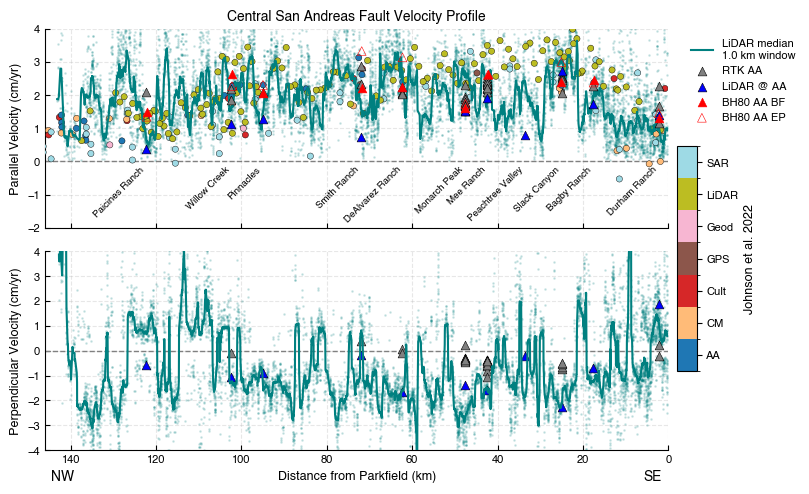

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib import rcParams

# =========================
# STYLE (publication ready)
# =========================
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'pdf.fonttype': 42
})

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 5),   # ⬅️ shorter x-direction
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1]}
)

color = 'teal'

# =========================
# -------- PARALLEL -------
# =========================
pts = par750.sort_values("dist_from_parkfield_m").reset_index(drop=True)
dist = pts["dist_from_parkfield_m"].values

# Lidar cloud
ax1.scatter(
    dist,
    -1 * pts['par_total_offset'],
    color=color,
    s=1,
    alpha=0.15,
    zorder=2
)

# Rolling median
window = 1000
med, mad = tt.rolling_dist_median(dist, -1 * pts['par_total_offset'], window)
ax1.plot(dist, med, color=color, linewidth=1.5, zorder=10, label=f'LiDAR median\n{np.round(window/1000)} km window')

# Johnson et al.
labels = cdf['Inst'].astype('category').cat.categories
n = len(labels)
cmap = plt.cm.get_cmap('tab20', n)
bounds = np.arange(-0.5, n + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

sc = ax1.scatter(
    cdf.dist_from_parkfield_m,
    cdf['Creep rate (mm/yr)'] / 10,
    c=cdf['Inst_i'],
    cmap=cmap,
    norm=norm,
    s=20,
    edgecolor='black',
    linewidth=0.3,
    zorder=5
)

# AA + LiDAR@AA + BH
ax1.scatter(
    aaERFdf["dist_from_parkfield_m"],
    aaERFdf['AA Parallel Fault Rate '] * -1,
    s=40, marker='^', color='grey',
    edgecolor='black', linewidth=0.4,
    label='RTK AA', zorder=11
)

ax1.scatter(
    lidERFdf["dist_from_parkfield_m"],
    lidERFdf['Lidar Parallel Fault Rate '] * -1,
    s=40, marker='^', color='blue',
    edgecolor='black', linewidth=0.4,
    label='LiDAR @ AA', zorder=11
)

ax1.scatter(
    bhdf_found["dist_from_parkfield_m"],
    bhdf_found['BF_mm_yr'] / 10,
    s=40, marker='^', facecolors='red',
    edgecolors='red', linewidth=0.4,
    label='BH80 AA BF', zorder=15
)
ax1.scatter(
    bhdf_found["dist_from_parkfield_m"],
    bhdf_found['EP_mm_yr'] / 10,
    s=40, marker='^', facecolors='none',
    edgecolors='red', linewidth=0.4,
    label='BH80 AA EP', zorder=15
)

# Labels for BH
for i in range(len(aaERFdf.Name.unique())):
    tdf = aaERFdf[aaERFdf.Name == aaERFdf.Name.unique()[i]]
    ax1.text(
        tdf["dist_from_parkfield_m"].values[0],
        -0.1,  # slight downward offset
        tdf.Name.values[0],
        rotation=45,
        fontsize=7,
        ha='right',
        va='top',
        clip_on=True,
        zorder=11
    )

ax1.set_ylabel('Parallel Velocity (cm/yr)')
ax1.set_title('Central San Andreas Fault Velocity Profile')
ax1.axhline(0, linestyle='--', color='gray', linewidth=1)
ax1.grid(True, linestyle='--', alpha=0.3)

# =========================
# ----- PERPENDICULAR -----
# =========================
pts = perp750.sort_values("dist_from_parkfield_m").reset_index(drop=True)
dist = pts["dist_from_parkfield_m"].values

ax2.scatter(
    dist,
    pts['perp_total_offset'],
    color=color,
    s=1,
    alpha=0.15,
    zorder=2
)

med, mad = tt.rolling_dist_median(dist, pts['perp_total_offset'], window)
ax2.plot(dist, med, color=color, linewidth=1.5, zorder=10)

# AA + LiDAR@AA (perp)
ax2.scatter(
    aaERFdf["dist_from_parkfield_m"],
    aaERFdf['AA Perpendicular Fault Rate '],
    s=40, marker='^', color='grey',
    edgecolor='black', linewidth=0.4,
    zorder=6
)

ax2.scatter(
    lidERFdf["dist_from_parkfield_m"],
    lidERFdf['Lidar Perpendicular Fault Rate '],
    s=40, marker='^', color='blue',
    edgecolor='black', linewidth=0.4,
    zorder=6
)

ax2.axhline(0, linestyle='--', color='gray', linewidth=1)
ax2.set_ylabel('Perpendicular Velocity (cm/yr)')
ax2.set_xlabel('Distance from Parkfield (km)')
ax2.grid(True, linestyle='--', alpha=0.3)

# =========================
# AXIS FORMATTING
# =========================
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='plain', axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in')
ax1.set_ylim([-2, 4])
ax2.set_ylim([-4, 4])

# invert x-axis
ax2.invert_xaxis()
ax2.set_xlim(146000, 0)  # explicit control

# km ticks
ticks = ax2.get_xticks()
from matplotlib.ticker import FuncFormatter
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f}"))

# Direction labels
ax2.text(
    0.99, -0.1, 'SE',
    transform=ax2.transAxes,
    ha='right', va='top', fontsize=10
)

ax2.text(
    0.01, -0.1, 'NW',
    transform=ax2.transAxes,
    ha='left', va='top', fontsize=10
)

# =========================
# LEGEND (top right)
# =========================
leg = ax1.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    frameon=False
)

# =========================
# COLORBAR (below legend)
# =========================
# Manually define colorbar axis [left, bottom, width, height]
cax = fig.add_axes([0.68, 0.25, 0.02, 0.45])  # tweak as needed

cbar = fig.colorbar(sc, cax=cax, ticks=np.arange(n))
cbar.ax.set_yticklabels(labels)
cbar.set_label('Johnson et al. 2022')

plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on right
plt.savefig(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window}.png',dpi=300)
plt.show()


In [ ]:
cdf.Inst.unique()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Function to compute MAD
def mad(x):
    median = np.median(x)
    return np.median(np.abs(x - median))

plt.figure(figsize=(12, 3.5))

# Rolling window in meters
window_m = 1000     # 1 km
half_w = window_m / 2

pts, fname = saf500,'500 m'

# Sort by distance from Parkfield
pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)
# Extract arrays
dist = pts["dist_from_parkfield_m"].values
npts = len(pts)
# Plot rolling median line (x-axis = distance)
plt.plot(
    dist,
    pts['perp_rolling_median'],
    color='teal',
    #s=0.7,
    linewidth=1,
    label=f'1 km Rolling Median ({fname})',
    zorder=7
)
## Plot shaded MAD bounds
plt.fill_between(
    dist,
    pts['perp_rolling_median'] - pts['perp_rolling_mad'],
    pts['perp_rolling_median'] + pts['perp_rolling_mad'],
    color='teal',
    alpha=0.2,
    label=f"± MAD ({fname})"
)

# Plot rolling median line (x-axis = distance)
plt.plot(
    dist,
    pts['par_rolling_median'],
    color='maroon',
    #s=0.7,
    linewidth=1,
    label=f'1 km Rolling Median ({fname})',
    zorder=7
)
## Plot shaded MAD bounds
plt.fill_between(
    dist,
    pts['par_rolling_median'] - pts['par_rolling_mad'],
    pts['par_rolling_median'] + pts['par_rolling_mad'],
    color='maroon',
    alpha=0.2,
    label=f"± MAD ({fname})"
)
# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )

# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Velocity (cm/yr)')
plt.title('Central San Andreas Fault Perpendicular Velocity')

plt.legend(
   #bbox_to_anchor=(1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

## Burford and Harsh v New AA Measurements v Lidar sampled


In [5]:
import rasterio
import matplotlib.pyplot as plt

In [6]:
subregion = [-120.818512, 36.219191, -120.785624, 36.232056]
subregion = [-120.86102, 36.16672,-120.72018,36.26133] 
smallreg1 = [-120.761,36.1783,-120.756,36.1825]
smallreg2 = [-120.7985,36.215,-120.797,36.216]

/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_90428/1175828272.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])


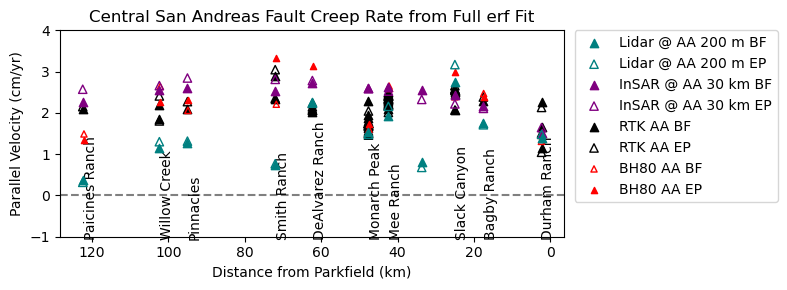

In [42]:
plt.figure(figsize=(8,3))

for i in range(len(bhdf_found)):
    plt.text(
       bhdf_found["dist_from_parkfield_m"].values[i], -1,
        bhdf_found.Site_Name.values[i],
        rotation=90,
    )
    
plt.scatter(
    lidERFdf["dist_from_parkfield_m"],
    -1 * lidERFdf['Lidar Parallel Fault Rate '],
    marker='^',
    facecolors='teal',
    edgecolors='teal',
    label='Lidar @ AA 200 m BF',
    zorder=23
)

plt.scatter(
    lidERFdf["dist_from_parkfield_m"],
    -1 * lidERFdf['Lidar Parallel EP Rate'],
    marker='^',
    facecolors='none',
    edgecolors='teal',
    label='Lidar @ AA 200 m EP',
    zorder=23
)
plt.scatter(
    sarERFdf["dist_from_parkfield_m"],
    -1 * sarERFdf['InSAR Parallel Fault Rate '],
    marker='^',
    facecolors='purple',
    edgecolors='purple',
    label='InSAR @ AA 30 km BF',
    zorder=22
)
plt.scatter(
    sarERFdf["dist_from_parkfield_m"],
    -1 * sarERFdf['InSAR Parallel EP Rate'],
    marker='^',
    facecolors='none',
    edgecolors='purple',
    label='InSAR @ AA 30 km EP',
    zorder=22
)
# New AA lt rates
plt.scatter(
    aaERFdf["dist_from_parkfield_m"],
    -1 * aaERFdf['AA Parallel Fault Rate '],
    #yerr=aaERFdf['AA Parallel Fault Rate Sigma'],
    #fmt='^',
    marker='^',
    color='black',
    label='RTK AA BF',
    zorder=20
)
plt.scatter(
    aaERFdf["dist_from_parkfield_m"],
    -1 * aaERFdf['AA Parallel EP Rate'],
    marker='^', 
    facecolors='none',
    edgecolors='black',
    label='RTK AA EP',
    zorder=20
)

# Burford & Harsh data
plt.scatter(
    bhdf_found["dist_from_parkfield_m"],
    bhdf_found.BF_mm_yr / 10,
    s=20,
    marker='^',
    facecolors='none',
    edgecolors='red',
    label='BH80 AA BF',
    zorder=21
)
plt.scatter(
    bhdf_found["dist_from_parkfield_m"],
    bhdf_found.EP_mm_yr / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA EP',
    zorder=21
)


# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Parallel Velocity (cm/yr)')
plt.title('Central San Andreas Fault Creep Rate from Full erf Fit')

plt.legend(#loc='upper left'
   bbox_to_anchor=(1.02, 1),
   borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
plt.savefig(
   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/AAcompilationWlidar.pdf',
    transparent=True,dpi=300)
plt.show()

In [37]:
bhdf_found


,Site_No,Site_Name,Key,Latitude_N,Longitude_W,P_km,L_m,DFS_yr_julian_day,DLS_yr_julian_day,NS,SZW_MAX_m,BF_mm_yr,EP_mm_yr,Lon84,Lat84,easting,northing,dist_from_parkfield_m
4,5,Paicines Ranch,True,36.7200,121.3467,330.0,157,72:299,77:221,10,10,14.9,13.5,121.3467,36.7200,-5.326053e+06,1.334888e+07,1.115986e+07
7,8,Willow Creek,True,36.5950,121.1850,350.6,75,72:216,77:025,7,13,26.4,22.7,121.1850,36.5950,-5.328593e+06,1.337773e+07,1.118548e+07
10,11,Pinnacles,True,36.5433,121.1350,357.7,202,72:301,77:026,5,10,20.6,23.1,121.1350,36.5433,-5.330972e+06,1.338798e+07,1.119538e+07
13,14,Smith Ranch,True,36.3833,120.9693,381.0,120,67:278,71:217,5,6,22.1,33.3,120.9693,36.3833,-5.337309e+06,1.342086e+07,1.122646e+07
14,15,DeAlvarez Ranch,True,36.3167,120.9017,390.5,138,70:225,77:236,7,15,22.5,31.4,120.9017,36.3167,-5.340001e+06,1.343443e+07,1.123934e+07
17,18,Monarch Peak,True,36.2133,120.7983,405.1,96,68:044,77:041,8,18,16.0,17.3,120.7983,36.2133,-5.344241e+06,1.345538e+07,1.125927e+07
18,19,Mee Ranch,True,36.1800,120.7567,410.4,200,70:238,77:235,7,5,26.5,26.0,120.7567,36.1800,-5.344898e+06,1.346297e+07,1.126601e+07
20,21,Slack Canyon,True,36.0650,120.6283,427.7,79,68:045,79:130,9,6,23.9,30.0,120.6283,36.0650,-5.348361e+06,1.348767e+07,1.128868e+07
21,22,Bagby Ranch,True,36.0150,120.5717,435.0,160,70:224,79:131,7,10,24.7,23.8,120.5717,36.0150,-5.349765e+06,1.349850e+07,1.129857e+07
22,23,Durham Ranch,True,35.8850,120.4217,454.8,32,68:046,79:118,9,9,13.1,14.6,120.4217,35.8850,-5.353070e+06,1.352698e+07,1.132435e+07


### mee

In [ ]:
dfmee = pd.DataFrame({'lon':aartk[aartk.Name == 'Mee Ranch'].Longitude, 
                     'lat':aartk[aartk.Name == 'Mee Ranch'].Latitude, 
                     'dx':aartk[aartk.Name == 'Mee Ranch']['Short-term East Velocity (cm/yr)'],
                     'dy':aartk[aartk.Name == 'Mee Ranch']['Short-term North Velocity (cm/yr)']})
dfmee

In [ ]:
# SUbregion
# Introductory figure base

fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain")

pygmt.config(FORMAT_GEO_MAP="ddd.xxx")
pygmt.config(FONT_LABEL="6p")
pygmt.config(FONT_ANNOT_PRIMARY="6p")
pygmt.config(FONT_ANNOT_SECONDARY="6p")

# Plot the base map of the main figure. 
region = [subregion[0],subregion[2],subregion[1],subregion[3]]
region = [smallreg1[0],smallreg1[2],smallreg1[1],smallreg1[3]]
#region = [smallreg2[0],smallreg2[2],smallreg2[1],smallreg2[3]]
fig.basemap(region=region, projection="M3c", frame=["ESnw", "a0.002f"])

# gridimage
pygmt.makecpt(cmap='polar',series=[-0.25,0.25],background='o',reverse=True)
#fig.grdimage(grid=dP,cmap=True)

# Fault Trace
#pts = pd.read_csv('/Volumes/Extreme Pro/Projects/Garlock/GIS/EastPoints.csv')
#pts.sort_values(by='Lon',ascending=True,inplace=True)
fig.plot('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Faults/DeLong2010/NewFaultsRevisionEPSG4326.shp',pen="0.5p,darkgreen")
fig.plot('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp',pen="0.5p,darkgreen")
#rectangle = [[e_inset[0], e_inset[2], e_inset[1], e_inset[3]]]
#fig.plot(data=rectangle, style="r+s", pen="0.55p,maroon")


# vectors, Mee1 and Mee2
fig.velo(dfmee,
         spec="e0.2/1+f6",
        pen="0.6p,maroon",
        line=True,
        vector="0.1c+p1p+e+gmaroon",)

# Scale
fig.velo(pd.DataFrame({'Lon':[-120.7595],'Lat':[36.1794],'dx':[1.0],'dy':[0.0],
                       'sigE':[0],'sigN':[0],'l':['1 cm/yr']})
         ,spec="e0.2/1+f6",
    #uncertaintyfill="lightblue1",
    pen="0.6p,black",
    line=True,
    vector="0.1c+p1p+e+gblack",)

fig.basemap(map_scale='JBR+w50e+o-2.7c/-.6c+lm',rose='jBL+l,,,N+o2/0.07+w0.5c')#'jBR+l,,,N+o1.8/1.7+w0.5c'
#fig.savefig(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Manuscripts/MRMR/Figures/meeAAmap.pdf',dpi=300)
fig.show()

In [ ]:
plt.scatter

### monarch

In [ ]:
# MONARCH PEAK MAP
# Introductory figure base

fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xxx")
pygmt.config(FONT_LABEL="6p")
pygmt.config(FONT_ANNOT_PRIMARY="6p")
pygmt.config(FONT_ANNOT_SECONDARY="6p")

# Plot the base map of the main figure. 
region = [subregion[0],subregion[2],subregion[1],subregion[3]]
region = [smallreg2[0],smallreg2[2],smallreg2[1],smallreg2[3]]
fig.basemap(region=region, projection="M3c", frame=["ESnw", "a0.001f"])

# gridimage
pygmt.makecpt(cmap='polar',series=[-0.25,0.25],background='o',reverse=True)
#fig.grdimage(grid=dP,cmap=True)

# Fault Trace
#pts = pd.read_csv('/Volumes/Extreme Pro/Projects/Garlock/GIS/EastPoints.csv')
#pts.sort_values(by='Lon',ascending=True,inplace=True)
fig.plot('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Faults/DeLong2010/NewFaultsRevisionEPSG4326.shp',pen="0.5p,darkgreen")
fig.plot('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp',pen="0.5p,darkgreen")
#rectangle = [[e_inset[0], e_inset[2], e_inset[1], e_inset[3]]]
#fig.plot(data=rectangle, style="r+s", pen="0.55p,maroon")


# vectors, MP
fig.velo(dfmp
         ,spec="e0.05/1+f18",
    #uncertaintyfill="lightblue1",
    pen="0.6p,maroon",
    line=True,
    vector="0.1c+p1p+e+gmaroon",)

# Scale
fig.velo(pd.DataFrame({'Lon':[-120.7984],'Lat':[36.21525],'dx':[0],'dy':[5],
                       'sigE':[0],'sigN':[0],'l':['5 mm/yr']})
         ,spec="e0.05/1+f6",
    #uncertaintyfill="lightblue1",
    pen="0.6p,black",
    line=True,
    vector="0.1c+p1p+e+gblack",)

fig.basemap(map_scale='JBR+w20e+o-2.7c/-.5c+lm',rose='jBL+l,,,N+o1/1.6+w0.5c')
#fig.savefig(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Manuscripts/MRMR/Figures/mpAAmap.pdf',dpi=300)
fig.show()

In [ ]:
image = rioxarray.open_rasterio('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/DisplacementRasters/MR_lidar_ew_demeaned.tif')
image = image.coarsen(x=10, y=10, boundary="pad").median()
EW = image.rio.reproject("EPSG:4326")
image = rioxarray.open_rasterio('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/DisplacementRasters/MR_lidar_ns_demeaned.tif')
image = image.coarsen(x=10, y=10, boundary="pad").median()
NS = image.rio.reproject("EPSG:4326")

image = rioxarray.open_rasterio('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/DisplacementRasters/MR_lidar_demeaned.tif')
parLidar = image.rio.reproject("EPSG:4326")

In [ ]:
dfvelo = pd.DataFrame({'lon':np.meshgrid(EW.x,EW.y)[0].flatten(), 
                     'lat':np.meshgrid(EW.x,EW.y)[1].flatten(), 
                     'dx':EW.data.flatten(),
                     'dy':NS.data.flatten()})
dfvelo = dfvelo[~dfvelo.isin([-9999]).any(axis=1)]
dfvelo.dx = dfvelo.dx
dfvelo.dy = dfvelo.dy
dfvelo['x'] = P(dfvelo.lon,dfvelo.lat)[0]
dfvelo['y'] = P(dfvelo.lon,dfvelo.lat)[1]

In [ ]:
# MONARCH PEAK MAP
# Introductory figure base

fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain",FORMAT_GEO_MAP="ddd.xx",FONT_ANNOT_PRIMARY="8p",FONT_ANNOT_SECONDARY="6p")

fig.basemap(
    projection="Oa-120.82/36.7/50/2.5c",
    # Set bottom left and top right coordinates of the figure with "+r"
    frame=["af"],
    region="-120.78/36.15/-120.82/36.29+r",
)

#pygmt.makecpt(cmap='polar',series=[-1.5,1.5],background='o',reverse=True)
#fig.grdimage(grid=parLidar,cmap=True)

#fig.plot(data='/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/GIS/DeLong2010/NewFaultsRevisionEPSG4326.shp', pen="0.17p,black")

fig.plot(x=fltptdf1.lon.values,y=fltptdf1.lat.values)
fig.plot(x=fltptdf2.lon.values,y=fltptdf2.lat.values)

fig.velo(dfvelo[::1400],
         spec="e0.07/0.05+f6",
    #uncertaintyfill="lightblue1",
    pen="0.1p,maroon",
    line=True,
    vector="0.05c+p0.6p+e+gmaroon",)

# Scale
fig.velo(pd.DataFrame({'Lon':[-120.7984],'Lat':[36.21525],'dx':[0],'dy':[5],
                       'sigE':[0],'sigN':[0],'l':['5 mm/yr']})
         ,spec="e0.08/0.08+f6",
    #uncertaintyfill="lightblue1",
    pen="0.6p,black",
    line=True,
    vector="0.1c+p1p+e+gblack",)

fig.basemap(map_scale='JBL+w1k+o-0.5c/-0.5c+l1km',rose='jBL+l,,,N+o0.2/0.6+w0.5c',box="+c0.05/0.02+gwhite@30,grey@30,solid")#+w1k+o-2c/-1c+lkm')#,box="+c0.1/0.3+gwhite@30+p0.5p,grey@30,solid",rose='jBR+l,,,N+o0.5/0.4+w0.75c')
#fig.savefig(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Manuscripts/MRMR/Figures/mpAAmap.pdf',dpi=300)
fig.show()

## 

## Fault Zone Width

How do widths compare with profile distance?

In [ ]:
par750

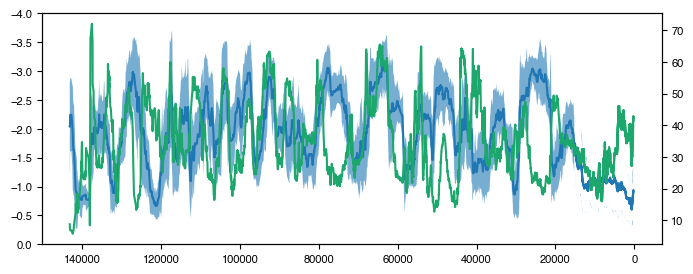

In [49]:
#plt.scatter(par750['dist_from_parkfield_m'],par750['par_total_offset'],s=0.2)
plt.figure(figsize=(8,3))
medp, mad = tt.rolling_dist_median(par750['dist_from_parkfield_m'],par750['par_total_offset'],2000)
plt.plot(par750['dist_from_parkfield_m'],medp)
plt.fill_between(par750['dist_from_parkfield_m'],medp+mad,medp-mad,alpha=0.6)
med, mad = tt.rolling_dist_median(par750['dist_from_parkfield_m'],par750['perp_total_offset'],2000)
#plt.plot(par750['dist_from_parkfield_m'],med)
#plt.fill_between(par750['dist_from_parkfield_m'],med+mad,med-mad,alpha=0.6)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.ylim([0,-4])
plt.twinx()
medw, mad = tt.rolling_dist_median(par750['dist_from_parkfield_m'],par750['par_shear_width'],2000)
plt.plot(par750['dist_from_parkfield_m'],medw,color="#1CA76D")
#plt.fill_between(par750['dist_from_parkfield_m'],medw+mad,medw-mad,alpha=0.6,color="#1CA76D")

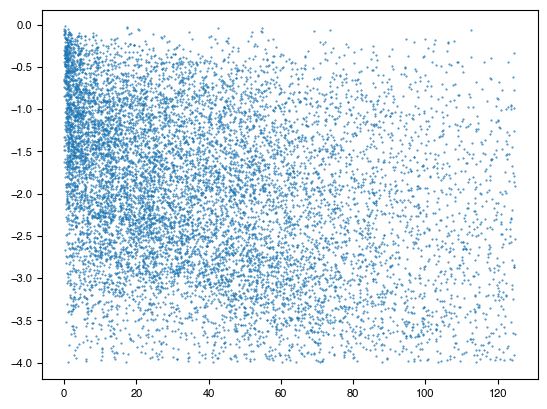

In [41]:
plt.scatter(par750['par_shear_width'],par750['par_total_offset'],s=0.2)

In [44]:
corr = par750.drop(columns=['geometry']).corr(method='pearson')
# Flatten the matrix and sort
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

print(corr_pairs.head(50))

Unnamed: 0             northing                 0.999854
northing               dist_from_parkfield_m    0.995487
Unnamed: 0             dist_from_parkfield_m    0.995477
par_total_offset       par_fzw_offset           0.912677
perp_total_offset      perp_fzw_offset          0.883201
par_slope2_sig         perp_slope1_sig          0.793060
par_total_offset_sig   par_slope2_sig           0.787277
perp_fzw_offset        perp_ep_offset           0.741904
par_slope2_sig         perp_slope2_sig          0.729344
perp_slope1_sig        perp_slope2_sig          0.709601
par_total_offset_sig   perp_slope2_sig          0.698384
par_fault_loc_sig      par_shear_width_sig      0.665857
par_fzw_offset         par_ep_offset            0.640939
par_total_offset_sig   perp_slope1_sig          0.625224
par_slope1             par_ep_offset            0.555696
par_intercept          par_slope1               0.548570
perp_total_offset      perp_ep_offset           0.546889
par_fault_loc          perp_fau

In [47]:
corr_pairs.par_total_offset.par_shear_width

np.float64(-0.29784863771639314)

In [ ]:
x, y = saf200['par_width_rolling_median'],saf200['perp_width_rolling_median']
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]
plt.scatter(x,y,s=0.2)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value**2)
print("p-value:", p_value)
print("Standard error:", std_err)

In [ ]:
import scipy.stats as stats
import numpy as np


plt.figure(figsize=(10,8))
for pts in [saf500]:#,saf500,saf1500]:
    x = pts["par_rolling_median"].values
    y = pts["par_width_rolling_median"].values
    c = pts['dist_from_parkfield_m'].values

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]
    c = c[mask]

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    print("Slope:", slope)
    print("Intercept:", intercept)
    print("R²:", r_value**2)
    print("p-value:", p_value)
    print("Standard error:", std_err)

    xp = np.linspace(min(x), max(x), 200)
    plt.scatter(x,y,c=c,s=0.2,cmap='magma')
    plt.plot(xp, intercept + slope*xp , linewidth=1)
plt.xlim(0,4.5)
plt.colorbar()
#plt.ylim(0,250)


In [ ]:
stats.linregress(x, y)

In [ ]:
plt.plot(saf500['par_rolling_median']-saf1500['par_rolling_median'])
plt.plot(saf200['par_rolling_median']-saf1500['par_rolling_median'])

plt.axhline(0)
plt.gca().invert_xaxis()  

In [ ]:
## Perpendicular
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Function to compute MAD
def mad(x):
    median = np.median(x)
    return np.median(np.abs(x - median))

plt.figure(figsize=(12, 3.5))

# Rolling window in meters
window_m = 1000     # 1 km
half_w = window_m / 2

for pts, color in zip([saf200,saf500,saf1500], ['teal','maroon','indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    vel = (pts["perp_total_offset"] * -1).values  # your sign convention
    npts = len(pts)

    # Prepare arrays for results
    rolling_median = np.full(npts, np.nan)
    rolling_mad = np.full(npts, np.nan)

    # Compute rolling median in a *distance window*
    for i in range(npts):
        # distance window: +/- 500 m
        lo = dist[i] - half_w
        hi = dist[i] + half_w

        mask = (dist >= lo) & (dist <= hi)
        vals = vel[mask]

        if len(vals) > 0:
            rolling_median[i] = np.median(vals)
            rolling_mad[i] = mad(vals)

    # Store in df
    if color == 'teal':
        saf200['perp_rolling_median'] = rolling_median
        saf200['perp_rolling_mad'] = rolling_mad
    elif color == 'maroon':
        saf500['perp_rolling_median'] = rolling_median
        saf500['perp_rolling_mad'] = rolling_mad    
    else:
        saf1500['perp_rolling_median'] = rolling_median
        saf1500['perp_rolling_mad'] = rolling_mad


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        rolling_median,
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'{window_m/1000} km Rolling Median ({fname})',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        rolling_median - rolling_mad,
        rolling_median + rolling_mad,
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )


# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='maroon',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )

# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Velocity (cm/yr)')
plt.title('Central San Andreas Fault Perpendicular Velocity')

plt.legend(
   #bbox_to_anchor=(1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

In [ ]:
plt.scatter(saf500['par_rolling_median'],saf500['perp_rolling_median'],s=0.2)
plt.ylim(0,10)

In [ ]:
np.mean(saf500['par_total_offset']/saf500['perp_total_offset'])

## Johnson et al 2022 added analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Proj, Geod
P = Proj('epsg:32610')
G = Geod(ellps='WGS84')

In [ ]:
Px, Py = P(-120.441, 35.899)
egdf = pd.read_csv('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/AlignmentArrayLidarERFRates_202603.csv')
egdf = egdf[egdf['Unnamed: 0'] != 'Topo Creek']
egdf["dist_from_parkfield_m"] = np.sqrt(
    (egdf.ref_easting - Px)**2 +
    (egdf.ref_northing - Py)**2
)

# RTK AA
f = '/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/AlignmentArrayVelocities_ALL_PAIRS_NEW.csv'
aartk = pd.read_csv(f,comment='#')
aartk.replace(-9999, np.nan, inplace=True)
aartk['easting'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[0]
aartk['northing'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[1]
aartk["dist_from_parkfield_m"] = np.sqrt(
    (aartk.easting - Px)**2 +
    (aartk.northing - Py)**2
)

In [ ]:
cdf = pd.read_csv('/Users/chanagan/Downloads/JohnsonEtAl2022CreepTable.csv')
cdf = cdf[((cdf.Latitude >= 35.8) & (cdf.Longitude <= 37.15))]

cdf['easting'] = P(cdf['Longitude'].values,cdf['Latitude'].values)[0]
cdf['northing'] = P(cdf['Longitude'].values,cdf['Latitude'].values)[1]
cdf["dist_from_parkfield_m"] = np.sqrt(
    (cdf.easting - Px)**2 +
    (cdf.northing - Py)**2
)
cdf = cdf[cdf.dist_from_parkfield_m < 150*1000]

# Enumerate inst type of creep rate measurements
cdf['Inst_i'] = np.empty(len(cdf))
cdf['Aperture'] = np.empty(len(cdf))
#'AA', 'CM', 'Cult', 'GPS', 'Geod', 'LiDAR', 'SAR'
aps = [100,70,10,5000,10000,1000,1000]
for i, inst, ap in zip(np.arange(len(np.unique(cdf.Inst))),np.unique(cdf.Inst),aps):
    cdf.loc[cdf['Inst'] == inst, 'Inst_i'] = np.ones(len(cdf[cdf.Inst == inst]))*i
    cdf.loc[cdf['Inst'] == inst, 'Aperture'] = np.ones(len(cdf[cdf.Inst == inst]))*ap

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm

cdf['Inst_i'] = cdf['Inst'].astype('category').cat.codes
labels = cdf['Inst'].astype('category').cat.categories

# number of categories
n = len(labels)

# discrete colormap
cmap = plt.cm.get_cmap('tab20', n)

# boundaries for categories
bounds = np.arange(-0.5, n + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8,4))

sc = plt.scatter(
    cdf.dist_from_parkfield_m,
    cdf['Creep rate (mm/yr)'],
    c=cdf['Inst_i'],
    cmap=cmap,
    norm=norm
)
cbar = plt.colorbar(sc, ticks=np.arange(n))
cbar.ax.set_yticklabels(labels)

ax = plt.gca()
ax.invert_xaxis()   

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm

cdf['Inst_i'] = cdf['Inst'].astype('category').cat.codes
labels = cdf['Inst'].astype('category').cat.categories

# number of categories
n = len(labels)

# discrete colormap
cmap = plt.cm.get_cmap('tab20', n)

# boundaries for categories
bounds = np.arange(-0.5, n + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8,4))

sc = plt.scatter(
    cdf.Aperture,
    cdf['Creep rate (mm/yr)'],
    c=cdf['Inst_i'],
    cmap=cmap,
    norm=norm
)
cbar = plt.colorbar(sc, ticks=np.arange(n))
cbar.ax.set_yticklabels(labels)

ax = plt.gca()
ax.invert_xaxis()  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib import patches
import matplotlib.cm as cm

cdf['Inst_i'] = cdf['Inst'].astype('category').cat.codes
labels = cdf['Inst'].astype('category').cat.categories

# number of categories
n = len(labels)

# discrete colormap
cmap = plt.cm.get_cmap('tab20', n)

# boundaries for categories
bounds = np.arange(-0.5, n + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8,4))

for i in range(len(cdf)):
    s = cdf.iloc[i]
    try:
        sig = float(s['sig (mm/yr)'])
    except:
        sig = 0
    rect = patches.Rectangle(((s.End+s.Start)/2, s['Creep rate (mm/yr)']), 
                        s.End-s.Start, 
                        sig, 
                        linewidth=1, alpha=0.6,edgecolor=cmap(norm(s['Inst_i'])), facecolor=cmap(norm(s['Inst_i'])))
    ax.add_patch(rect)

ax.autoscale()

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n))
cbar.ax.set_yticklabels(labels)
ax.set_ylabel('Creep Rate (mm/yr)')
ax.set_xlabel('Date Range')
#ax.invert_xaxis()   
fig.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm
import matplotlib.cm as cm

# Category encoding
cdf['Inst_i'] = cdf['Inst'].astype('category').cat.codes
labels = cdf['Inst'].astype('category').cat.categories
n = len(labels)

# Colormap
cmap = plt.cm.get_cmap('tab20', n)
bounds = np.arange(-0.5, n + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8,4))

# -------------------------------
# Plot errorbars by category
# -------------------------------
for i, label in enumerate(labels):
    sub = cdf[cdf['Inst'] == label]
    
    x = sub['dist_from_parkfield_m'].values / 1000
    y = sub['Creep rate (mm/yr)'].values
    
    # handle missing sig
    try:
        sig = sub['sig (mm/yr)'].fillna(0).astype(float).values
    except:
        sig = np.zeros(len(sub))
    
    ax.errorbar(
        x, y,
        yerr=sig,
        fmt='o',                      # marker
        color=cmap(norm(i)),
        ecolor=cmap(norm(i)),
        markersize=2,
        elinewidth=1,
        capsize=3,
        label=label
    )

# -------------------------------
# Colorbar (categorical)
# -------------------------------
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n))
cbar.ax.set_yticklabels(labels)

# Labels
ax.set_ylabel('Creep Rate (mm/yr)')
ax.set_xlabel('Distance from Parkfield (km)')
ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Midpoint and half-range
cdf['Date_mid'] = (cdf['End'] + cdf['Start']) / 2
cdf['Date_err'] = (cdf['End'] - cdf['Start']) 

# Marker mapping
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
insts = cdf['Inst'].astype('category').cat.categories
marker_map = {inst: markers[i % len(markers)] for i, inst in enumerate(insts)}

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(10,5))

for inst in insts:
    sub = cdf[cdf['Inst'] == inst]
    
    x = sub['dist_from_parkfield_m'].values / 1000
    y = sub['Date_mid']
    yerr = sub['Date_err']
    
    sc = ax.errorbar(
        x, y,
        yerr=yerr,
        fmt=marker_map[inst],
        linestyle='none',
        color='k',  # marker edge
        ecolor='gray',
        alpha=0.7,
        capsize=2,
        label=inst
    )
    
    # scatter on top for color (since errorbar doesn't map colormap well)
    sc = ax.scatter(
        x, y,
        c=sub['Creep rate (mm/yr)'],
        cmap='magma',
        marker=marker_map[inst], linewidth=0.1,
        edgecolor='k', zorder=10
    )

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Creep rate (mm/yr)')

# Labels
ax.set_xlabel('Distance from Parkfield (km)')
ax.set_ylabel('Date')
ax.invert_xaxis()

# Legend
ax.legend(title='Instrument', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
plot_order

In [ ]:
# Ensure dates are datetime
cdf['Start'] = cdf['Start']
cdf['End'] = cdf['End']

# Compute measurement span in years
cdf['span_years'] = (cdf['End'] - cdf['Start'])

# Unique instruments
insts = cdf['Inst'].astype('category').cat.categories

# Map instruments to markers and colors
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
colors = plt.cm.tab10.colors  # pick up to 10 distinct colors
marker_map = {inst: markers[i % len(markers)] for i, inst in enumerate(insts)}
color_map = {inst: colors[i % len(colors)] for i, inst in enumerate(insts)}

# Optional: define plotting order (LiDAR first)
if 'LiDAR' in insts:
    plot_order = ['LiDAR'] + [i for i in insts if i != 'LiDAR']
else:
    plot_order = insts

# -------------------------------
# Plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(10,5))

# Primary axis: creep rate
for inst in insts:
    sub = cdf[cdf['Inst'] == inst]
    x = sub['dist_from_parkfield_m'].values / 1000
    y = sub['Creep rate (mm/yr)'].values
    yerr = sub['span_years'].values / 2  # error bar = half timespan
    
    # Assign zorder: LiDAR lowest
    z = 0 if inst == 'LiDAR' else i + 1

    ax1.errorbar(
        x, y,
        yerr=yerr,
        fmt=marker_map[inst],
        markersize=7,
        linestyle='none',
        markerfacecolor=color_map[inst],
        markeredgecolor='none',
        ecolor=color_map[inst],
        elinewidth=1.5,
        capsize=1,
        label=inst,
        zorder=z
    )

ax1.set_xlabel('Distance from Parkfield (km)')
ax1.set_ylabel('Creep rate (mm/yr)')
ax1.invert_xaxis()

# Secondary axis: span
ax2 = ax1.twinx()
ax2.set_ylabel('Measurement span (years)')
ax2.set_ylim(ax1.get_ylim())  # optional: sync scale if desired

# -------------------------------
# Legend
# -------------------------------
ax1.legend(title='Instrument', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
0.002*111

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure dates are datetime
cdf['Start'] = pd.to_datetime(cdf['Start'])
cdf['End'] = pd.to_datetime(cdf['End'])

# Compute measurement span in years
cdf['span_years'] = (cdf['End'] - cdf['Start']).dt.days / 365.25

# Unique instruments
insts = cdf['Inst'].astype('category').cat.categories

# Map instruments to markers and colors
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
colors = plt.cm.tab10.colors  # up to 10 distinct colors
marker_map = {inst: markers[i % len(markers)] for i, inst in enumerate(insts)}
color_map = {inst: colors[i % len(colors)] for i, inst in enumerate(insts)}

# -------------------------------
# Plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(10,5))

# Optional: define plotting order (LiDAR first)
if 'LiDAR' in insts:
    plot_order = ['LiDAR'] + [i for i in insts if i != 'LiDAR']
else:
    plot_order = insts

# Primary axis: creep rate with timespan errorbars
for inst in plot_order:
    sub = cdf[cdf['Inst'] == inst]
    x = sub['dist_from_parkfield_m'].values / 1000
    y = sub['Creep rate (mm/yr)'].values
    yerr = sub['span_years'].values / 2
    
    ax1.errorbar(
        x, y,
        yerr=yerr,
        fmt=marker_map[inst],
        markersize=8,
        markerfacecolor=color_map[inst],
        markeredgecolor='k',
        ecolor=color_map[inst],  # error bars colored by instrument
        elinewidth=2,
        capsize=3,
        label=inst
    )

ax1.set_xlabel('Distance from Parkfield (km)')
ax1.set_ylabel('Creep rate (mm/yr)')
ax1.invert_xaxis()

# Secondary y-axis: measurement span (optional)
ax2 = ax1.twinx()
ax2.set_ylabel('Measurement span (years)')
ax2.set_ylim(ax1.get_ylim())  # optional: sync with primary axis

# Legend
ax1.legend(title='Instrument', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
cdf

## Create Raster Vector Image

In [ ]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import pygmt
from pyproj import Proj, Geod
from osgeo import gdal
import pygmt
import rioxarray

import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

P = Proj('epsg:32610')
G = Geod(ellps='WGS84')

In [ ]:
image = rioxarray.open_rasterio('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/EW_velocity_merged1m.tif')
image = image.coarsen(x=100, y=100, boundary="pad").median()
EW = image.rio.reproject("EPSG:4326")
image = rioxarray.open_rasterio('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/NS_velocity_merged1m.tif')
image = image.coarsen(x=100, y=100, boundary="pad").median()
NS = image.rio.reproject("EPSG:4326")

In [ ]:
dfvelo = pd.DataFrame({'lon':np.meshgrid(EW.x,EW.y)[0].flatten(), 
                     'lat':np.meshgrid(EW.x,EW.y)[1].flatten(), 
                     'dx':EW.data.flatten(),
                     'dy':NS.data.flatten()})
dfvelo = dfvelo[~dfvelo.isin([-9999]).any(axis=1)]
dfvelo.dx = dfvelo.dx
dfvelo.dy = dfvelo.dy
dfvelo['x'] = P(dfvelo.lon,dfvelo.lat)[0]
dfvelo['y'] = P(dfvelo.lon,dfvelo.lat)[1]

In [ ]:
# Velocity vector map bigggg
fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain",FORMAT_GEO_MAP="ddd.xx",FONT_ANNOT_PRIMARY="8p",FONT_ANNOT_SECONDARY="6p")

fig.basemap(
    projection="M100c",
    # Set bottom left and top right coordinates of the figure with "+r"
    frame=["af"],
    region="-121.556530067973/35.816206095320716/-120.29034494759233/36.81875217249728+r",
)

fig.velo(dfvelo,
         spec="e0.08/0.05+f6",
    #uncertaintyfill="lightblue1",
    pen="0.1p,maroon",
    line=True,
    vector="0.03c+p0.6p+e+gmaroon",)

# Scale
fig.velo(pd.DataFrame({'Lon':[-120.9],'Lat':[36.21525],'dx':[0],'dy':[5],
                       'sigE':[0],'sigN':[0],'l':['5 mm/yr']}),
         spec="e0.08/0.05+f6",
    #uncertaintyfill="lightblue1",
    pen="0.6p,black",
    line=True,
     vector="0.03c+p0.6p+e+gblack",)

fig.basemap(map_scale='JBL+w1k+o-0.5c/-0.5c+l1km',rose='jBL+l,,,N+o0.2/0.6+w0.5c',box="+c0.05/0.02+gwhite@30,grey@30,solid")#+w1k+o-2c/-1c+lkm')#,box="+c0.1/0.3+gwhite@30+p0.5p,grey@30,solid",rose='jBR+l,,,N+o0.5/0.4+w0.75c')
fig.savefig(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VectorMapMassive.tif',dpi=1200)
fig.show()

In [ ]:
# Velocity vector map bigggg
fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain",FORMAT_GEO_MAP="ddd.xx",FONT_ANNOT_PRIMARY="8p",FONT_ANNOT_SECONDARY="6p")

fig.basemap(
    projection="M10c",
    # Set bottom left and top right coordinates of the figure with "+r"
    frame=["af"],
    region="-120.694688/36.119983/-120.691402/36.126214+r",
)

fig.velo(dfvelo,
         spec="e0.2/0.05+f6",
    #uncertaintyfill="lightblue1",
    pen="0.1p,maroon",
    line=True,
    vector="0.05c+p0.6p+e+gmaroon",)



#fig.basemap(map_scale='JBL+w1k+o-0.5c/-0.5c+l1km',rose='jBL+l,,,N+o0.2/0.6+w0.5c',box="+c0.05/0.02+gwhite@30,grey@30,solid")#+w1k+o-2c/-1c+lkm')#,box="+c0.1/0.3+gwhite@30+p0.5p,grey@30,solid",rose='jBR+l,,,N+o0.5/0.4+w0.75c')
#fig.savefig(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VectorMapMassive.tif',dpi=1200)
fig.show()